In [1]:
# ── 0.1  Mount Google Drive and clone/pull the repository ─────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir('/content')
!git clone https://github.com/VAL-Jerono/KHS_housing_dissertation.git 2>/dev/null || \
    (cd KHS_housing_dissertation && git pull)
os.chdir('KHS_housing_dissertation')
sys.path.insert(0, 'src')
print("✓ Drive mounted. Repository ready.")


Mounted at /content/drive
✓ Drive mounted. Repository ready.


In [13]:
# ── 0.2  Install all required dependencies (first run only — ~90 seconds) ──────
!pip install -q polars pyarrow scikit-learn matplotlib seaborn pyreadstat scipy \
    xgboost lightgbm shap pytorch-tabnet geopandas statsmodels \
    mapclassify contextily imbalanced-learn joblib upsetplot
print("✓ All packages installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 67.0 MB/s eta 0:00:00
✓ All packages installed.


In [14]:
# ── 0.3  Core imports ─────────────────────────────────────────────────────────
import json, warnings, pickle
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ── Sklearn ────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (StratifiedKFold, StratifiedGroupKFold,
                                      KFold, cross_val_predict,
                                      RandomizedSearchCV, train_test_split)
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                              classification_report, confusion_matrix,
                              mean_squared_error, r2_score, mean_absolute_error,
                              precision_recall_curve, roc_curve)
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer

# ── Boosting + Deep Learning ───────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb
import shap
import torch
import torch.nn as nn
from pytorch_tabnet.tab_model import TabNetRegressor, TabNetClassifier

import joblib
warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
print(f"✓ All imports loaded.")
print(f"  XGBoost {xgb.__version__} | LightGBM {lgb.__version__} | SHAP {shap.__version__}")
print(f"  PyTorch {torch.__version__}")


✓ All imports loaded.
  XGBoost 3.2.0 | LightGBM 4.6.0 | SHAP 0.51.0
  PyTorch 2.11.0+cpu


In [15]:
# ── 0.4  Paths, constants, colour palette, plot style, county map ─────────────

DRIVE  = Path('/content/drive/MyDrive/KHS_Dissertation')
PQ     = DRIVE / 'data' / 'parquet'
RAW    = DRIVE / 'data' / 'raw'
OUT    = DRIVE / 'outputs'
FIGS   = OUT / 'figures'
TABS   = OUT / 'tables'
MODS   = OUT / 'models'
SHPS   = DRIVE / 'data' / 'shapefiles'
for p in [FIGS, TABS, MODS, SHPS]: p.mkdir(parents=True, exist_ok=True)

# ── Global constants ───────────────────────────────────────────────────────────
N_FOLDS        = 5       # Cross-validation folds
SEED           = 42      # Random seed — propagated everywhere
HFVS_THRESHOLD = 0.60    # Score above which a household is classified "high vulnerability"

# ── Colour palette (defined once, used in every chart) ─────────────────────────
TEAL   = '#00695C'
RED    = '#B71C1C'
AMBER  = '#E65100'
BLUE   = '#1565C0'
PURPLE = '#6A1B9A'
GRAY   = '#546E7A'
DARK   = '#2C2C2A'

# ── Publication plot style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 140,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F8F8F6',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : '600',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'font.family'       : 'sans-serif',
    'legend.framealpha' : 0.9,
    'legend.fontsize'   : 9,
})

# ── All 47 Kenya counties (survey integer code → county name string) ─────────
COUNTY_MAP = {
     1:'Mombasa',        2:'Kwale',          3:'Kilifi',         4:'Tana River',
     5:'Lamu',           6:'Taita-Taveta',   7:'Garissa',        8:'Wajir',
     9:'Mandera',       10:'Marsabit',      11:'Isiolo',        12:'Meru',
    13:'Tharaka-Nithi', 14:'Embu',          15:'Kitui',         16:'Machakos',
    17:'Makueni',       18:'Nyandarua',     19:'Nyeri',         20:'Kirinyaga',
    21:"Murang'a",      22:'Kiambu',        23:'Turkana',       24:'West Pokot',
    25:'Samburu',       26:'Trans Nzoia',   27:'Uasin Gishu',   28:'Elgeyo-Marakwet',
    29:'Nandi',         30:'Baringo',       31:'Laikipia',      32:'Nakuru',
    33:'Narok',         34:'Kajiado',       35:'Kericho',       36:'Bomet',
    37:'Kakamega',      38:'Vihiga',        39:'Bungoma',       40:'Busia',
    41:'Siaya',         42:'Kisumu',        43:'Homa Bay',      44:'Migori',
    45:'Kisii',         46:'Nyamira',       47:'Nairobi',
}

print(f"✓ Environment configured.")
print(f"  FIGS: {FIGS}")
print(f"  TABS: {TABS}")
print(f"  Counties defined: {len(COUNTY_MAP)}")

✓ Environment configured.
  FIGS: /content/drive/MyDrive/KHS_Dissertation/outputs/figures
  TABS: /content/drive/MyDrive/KHS_Dissertation/outputs/tables
  Counties defined: 47


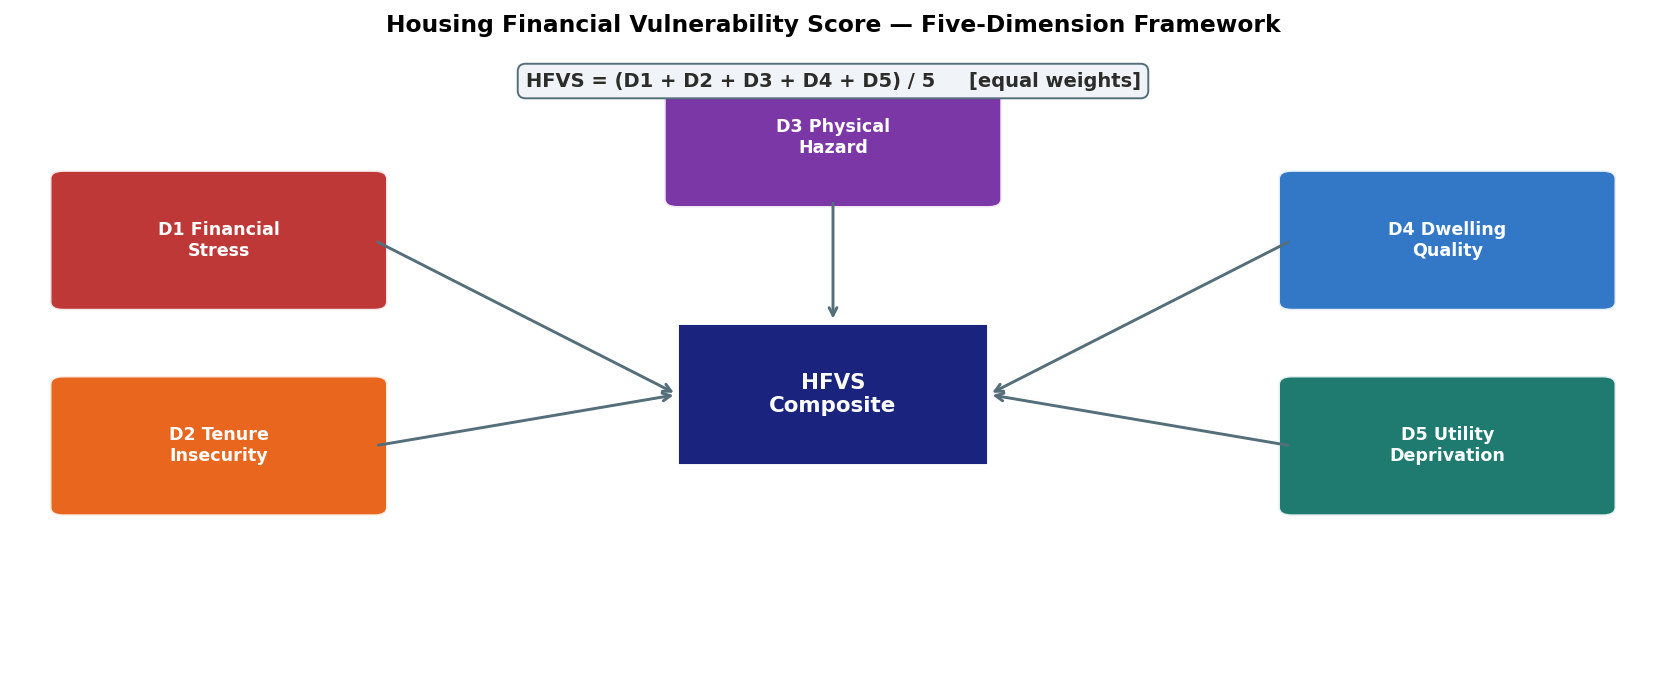

In [16]:
# ── 1.4  Visualise the HFVS Framework ─────────────────────────────────────────
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis('off')

BOX_W, BOX_H = 1.9, 1.2

# Central HFVS box
ax.add_patch(mpatches.Rectangle((4.05, 2.0), BOX_W, 1.4,
             fc='#1a237e', ec='white', lw=2, zorder=3))
ax.text(5.0, 2.7, 'HFVS\nComposite', ha='center', va='center',
        color='white', fontsize=11, fontweight='bold', zorder=4)

# Five dimension boxes
dims = [
    (0.3,  4.8, 'D1 Financial\nStress',    RED   ),   # top-left
    (0.3,  2.8, 'D2 Tenure\nInsecurity',   AMBER ),   # bottom-left
    (4.05, 5.8, 'D3 Physical\nHazard',     PURPLE),   # top-centre
    (7.8,  4.8, 'D4 Dwelling\nQuality',    BLUE  ),   # top-right
    (7.8,  2.8, 'D5 Utility\nDeprivation', TEAL  ),   # bottom-right
]

for bx, by, label, color in dims:
    ax.add_patch(mpatches.FancyBboxPatch((bx, by - BOX_H), BOX_W, BOX_H,
                 boxstyle='round,pad=0.08', fc=color, ec='white', lw=1.5, alpha=0.88))
    ax.text(bx + BOX_W/2, by - BOX_H/2, label,
            ha='center', va='center', color='white', fontsize=9, fontweight='bold')

    # Arrow routing —
    if bx < 4:        # left → right edge to left face of HFVS
        x_start, y_start = bx + BOX_W,   by - BOX_H/2
        x_end,   y_end   = 4.05,          2.7
    elif bx > 6:      # right → left edge to right face of HFVS
        x_start, y_start = bx,            by - BOX_H/2
        x_end,   y_end   = 4.05 + BOX_W,  2.7
    else:             # D3 top-centre → bottom edge down to top face of HFVS
        x_start, y_start = bx + BOX_W/2,  by - BOX_H
        x_end,   y_end   = 5.0,            2.0 + 1.4

    ax.annotate('', xy=(x_end, y_end), xytext=(x_start, y_start),
                arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.5,
                                connectionstyle='arc3,rad=0.0'))

# Title & formula
ax.text(5.0, 5.75, 'HFVS = (D1 + D2 + D3 + D4 + D5) / 5     [equal weights]',
        ha='center', va='center', fontsize=10, fontweight='600', color=DARK,
        bbox=dict(boxstyle='round', fc='#F0F4F8', ec=GRAY, pad=0.4))
ax.set_title('Housing Financial Vulnerability Score — Five-Dimension Framework',
             fontsize=12, fontweight='700', pad=12)

plt.tight_layout()
plt.savefig(FIGS / 'phase1_hfvs_framework.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:
# ── 2.1  Load codebook labels ─────────────────────────────────────────────────
# The KHS uses Stata-style integer codes for categorical variables.
# The JSON label files map code → label string for audit and interpretation.

with open(PQ / 'household_variable_labels.json')  as f: HH_VAR  = json.load(f)
with open(PQ / 'household_value_labels.json')     as f: HH_VAL  = json.load(f)
with open(PQ / 'dwelling_variable_labels.json')   as f: DW_VAR  = json.load(f)
with open(PQ / 'dwelling_value_labels.json')      as f: DW_VAL  = json.load(f)
with open(PQ / 'individual_variable_labels.json') as f: IND_VAR = json.load(f)

def decode(col, series, val_dict=HH_VAL):
    mapping = val_dict.get(col.upper(), val_dict.get(col, {}))
    return series.map(lambda x: mapping.get(str(int(x)), str(x)) if pd.notna(x) else np.nan)

print("✓ Codebook labels loaded.")
print(f"  Household variable labels : {len(HH_VAR):,}")
print(f"  Household value labels    : {len(HH_VAL):,}")
print(f"  Dwelling variable labels  : {len(DW_VAR):,}")

✓ Codebook labels loaded.
  Household variable labels : 392
  Household value labels    : 121
  Dwelling variable labels  : 25


In [18]:
# ── 2.2  File inventory — establish the full data universe ────────────────────
FILES = {
    'household' : 'Household_Information_Data.parquet',
    'individual': 'Individual_Data.parquet',
    'dwelling'  : 'Dwelling_Units_Data.parquet',
    'county'    : 'County_Physical_Planning_Data.parquet',
    'mortgage'  : 'Housing_Mortgage_Data.parquet',
    'loan'      : 'Housing_Loans_Data.parquet',
}

DESCRIPTIONS = {
    'household' : 'SPINE — 392 cols: finances, tenure, utilities, infrastructure',
    'individual': 'One row per person — demographics, education, migration, employment',
    'dwelling'  : 'Physical structure details — materials, rooms, floor area',
    'county'    : '47 rows — county-level planning data, infrastructure indicators',
    'mortgage'  : 'Mortgage records for borrowing households',
    'loan'      : 'Housing loan records',
}

print(f"  {'File':<13} {'Rows':>8} {'Cols':>6}  Description")
print("  " + "─" * 72)
dfs = {}
for key, fname in FILES.items():
    path = PQ / fname
    if not path.exists():
        print(f"  {'⚠ '+key:<13} {'—':>8} {'—':>6}  Not found")
        continue
    df = pl.read_parquet(path).to_pandas()
    dfs[key] = df
    print(f"  {key:<13} {df.shape[0]:>8,} {df.shape[1]:>6}  {DESCRIPTIONS.get(key,'')}")

hh       = dfs.get('household')
ind      = dfs.get('individual')
dw       = dfs.get('dwelling')
cnt      = dfs.get('county')
mortgage = dfs.get('mortgage', pd.DataFrame())   # ← was missing
loan     = dfs.get('loan',     pd.DataFrame())   # ← was missing

print(f"\n✓ Survey universe: {hh.shape[0]:,} households across {hh['a01'].nunique()} counties.")
print(f"  Individual records: {ind.shape[0]:,} people ({ind.shape[0]/hh.shape[0]:.1f} per household avg)")
print(f"  Dwelling records  : {dw.shape[0]:,} dwelling units")
print(f"  Mortgage records  : {len(mortgage):,}")
print(f"  Loan records      : {len(loan):,}")

  File              Rows   Cols  Description
  ────────────────────────────────────────────────────────────────────────
  household       21,347    392  SPINE — 392 cols: finances, tenure, utilities, infrastructure
  individual      80,889     97  One row per person — demographics, education, migration, employment
  dwelling        25,116     25  Physical structure details — materials, rooms, floor area
  county              47    116  47 rows — county-level planning data, infrastructure indicators
  mortgage         1,644     13  Mortgage records for borrowing households
  loan               946     10  Housing loan records

✓ Survey universe: 21,347 households across 47 counties.
  Individual records: 80,889 people (3.8 per household avg)
  Dwelling records  : 25,116 dwelling units
  Mortgage records  : 1,644
  Loan records      : 946


# ***EXPLORATION***

In [19]:
# ── STEP 1: Full raw directory inventory ──────────────────────────────────────
# Before loading anything, we want to know EXACTLY what files exist,
# their sizes, and whether they have parquet equivalents already converted.

import os
from pathlib import Path

print("=" * 70)
print("RAW DATA DIRECTORY — FULL INVENTORY")
print("=" * 70)

raw_files = sorted(RAW.glob("*.dta"))
pq_files  = {p.stem: p for p in PQ.glob("*.parquet")}

print(f"\n{'File':<45} {'Size (MB)':>10}  {'Parquet?':>10}")
print("─" * 70)

for f in raw_files:
    size_mb  = f.stat().st_size / 1_048_576
    has_pq   = "✓ yes" if f.stem in pq_files else "✗ no"
    print(f"  {f.name:<43} {size_mb:>9.2f}  {has_pq:>10}")

print(f"\n  Total .dta files : {len(raw_files)}")
print(f"  Already as .pq   : {len(pq_files)}")
print(f"  Need conversion  : {len(raw_files) - len(pq_files)}")

RAW DATA DIRECTORY — FULL INVENTORY

File                                           Size (MB)    Parquet?
──────────────────────────────────────────────────────────────────────
  County_Physical_Planning_Data.dta                0.11       ✓ yes
  Dwelling_Units_Data.dta                          6.44       ✓ yes
  Household_Information_Data.dta                  70.98       ✓ yes
  Housing_Financiers_Data.dta                      0.29       ✓ yes
  Housing_Loans_Data.dta                           0.10       ✓ yes
  Housing_Mortgage_Data.dta                        0.17       ✓ yes
  Individual_Data.dta                             60.26       ✓ yes
  KHS_Institutional_Data.dta                       0.61       ✓ yes
  Land_Parcels_Data.dta                            0.82       ✓ yes
  NEMA_Data_Set.dta                                0.05       ✓ yes
  Project Information.dta                          0.18       ✓ yes
  Real_Estate_Dataset.dta                          7.18       ✓ yes
  Type 

In [25]:
# ── STEP 2: Convert all remaining .dta files → parquet ────────────────────────
# pyreadstat preserves Stata value labels; we save both the data and
# a labels JSON so every downstream cell can decode integer codes.

import pyreadstat
import json

print("Converting .dta files not yet in parquet...\n")

conversion_log = {}

for f in sorted(RAW.glob("*.dta")):
    stem   = f.stem
    pq_out = PQ / f"{stem}.parquet"
    lb_out = PQ / f"{stem}_value_labels.json"

    if pq_out.exists():
        print(f"  ✓ {stem:<45} (already converted)")
        continue

    try:
        df, meta = pyreadstat.read_dta(str(f))

        # Save data as parquet
        df.to_parquet(pq_out, index=False)

        # Save variable labels  (col_name → description string)
        var_labels = meta.column_labels
        var_label_dict = dict(zip(meta.column_names, meta.column_labels))

        # Save value labels  (col_name → {code: label})
        val_labels = {}
        for col, mapping in meta.variable_value_labels.items():
            val_labels[col] = {str(int(k)): v for k, v in mapping.items()}

        combined = {"variable_labels": var_label_dict, "value_labels": val_labels}
        with open(lb_out, 'w') as jf:
            json.dump(combined, jf, indent=2)

        conversion_log[stem] = {
            'rows': df.shape[0], 'cols': df.shape[1],
            'var_labels': len(var_label_dict),
            'val_label_cols': len(val_labels)
        }
        print(f"  → {stem:<45} {df.shape[0]:>7,} rows × {df.shape[1]:>4} cols")

    except Exception as e:
        print(f"  ✗ {stem:<45} ERROR: {e}")

print(f"\n✓ Conversion complete. {len(conversion_log)} new files written to {PQ}")

Converting .dta files not yet in parquet...

  ✓ County_Physical_Planning_Data                 (already converted)
  ✓ Dwelling_Units_Data                           (already converted)
  ✓ Household_Information_Data                    (already converted)
  ✓ Housing_Financiers_Data                       (already converted)
  ✓ Housing_Loans_Data                            (already converted)
  ✓ Housing_Mortgage_Data                         (already converted)
  ✓ Individual_Data                               (already converted)
  ✓ KHS_Institutional_Data                        (already converted)
  ✓ Land_Parcels_Data                             (already converted)
  ✓ NEMA_Data_Set                                 (already converted)
  ✓ Project Information                           (already converted)
  ✓ Real_Estate_Dataset                           (already converted)
  ✓ Type of Housing Units                         (already converted)
  ✓ Water_Services_Providers_Data            

In [26]:
# ── STEP 3: Load ALL files + their label metadata ─────────────────────────────
# For each file we load: the dataframe, its variable labels (col descriptions),
# and its value labels (integer code → string meaning).
# This gives us the full picture of what each file actually contains.

ALL_FILES = {
    # Already loaded
    'household'    : 'Household_Information_Data',
    'individual'   : 'Individual_Data',
    'dwelling'     : 'Dwelling_Units_Data',
    'county'       : 'County_Physical_Planning_Data',
    'mortgage'     : 'Housing_Mortgage_Data',
    'loan'         : 'Housing_Loans_Data',
    # New — previously unused
    'land_parcels' : 'Land_Parcels_Data',
    'nema'         : 'NEMA_Data_Set',
    'water_svc'    : 'Water_Services_Providers_Data',
    'real_estate'  : 'Real_Estate_Dataset',
    'financiers'   : 'Housing_Financiers_Data',
    'institutional': 'KHS_Institutional_Data',
    'project_info' : 'Project Information',
    'housing_types': 'Type of Housing Units',
}

all_dfs    = {}
all_labels = {}   # key → {'variable_labels': {}, 'value_labels': {}}

print(f"{'Key':<16} {'Rows':>8} {'Cols':>6}  {'VarLabels':>10}  {'ValLabelCols':>13}  Description")
print("─" * 90)

for key, stem in ALL_FILES.items():
    pq_path = PQ / f"{stem}.parquet"
    lb_path = PQ / f"{stem}_value_labels.json"

    if not pq_path.exists():
        # Try converting on the fly if .dta exists
        dta_path = RAW / f"{stem}.dta"
        if dta_path.exists():
            df, meta = pyreadstat.read_dta(str(dta_path))
            df.to_parquet(pq_path, index=False)
            var_lbl = dict(zip(meta.column_names, meta.column_labels))
            val_lbl = {col: {str(int(k)): v for k, v in mapping.items()}
                       for col, mapping in meta.variable_value_labels.items()}
            labels  = {"variable_labels": var_lbl, "value_labels": val_lbl}
            with open(lb_path, 'w') as jf:
                json.dump(labels, jf, indent=2)
        else:
            print(f"  ✗ {key:<16} — file not found in raw or parquet")
            continue
    else:
        df = pd.read_parquet(pq_path)
        labels = {}
        if lb_path.exists():
            with open(lb_path) as jf:
                labels = json.load(jf)

    all_dfs[key]    = df
    all_labels[key] = labels

    vl_count  = len(labels.get('variable_labels', {}))
    val_count = len(labels.get('value_labels',    {}))
    # First variable label as a short description of the file
    first_desc = list(labels.get('variable_labels', {}).values())[:1]
    first_desc = first_desc[0][:40] if first_desc else "—"

    print(f"  {key:<16} {df.shape[0]:>8,} {df.shape[1]:>6}  {vl_count:>10}  {val_count:>13}  ...")

print(f"\n✓ {len(all_dfs)} files loaded.")

Key                  Rows   Cols   VarLabels   ValLabelCols  Description
──────────────────────────────────────────────────────────────────────────────────────────
  household          21,347    392           0              0  ...
  individual         80,889     97           0              0  ...
  dwelling           25,116     25           0              0  ...
  county                 47    116           0              0  ...
  mortgage            1,644     13           0              0  ...
  loan                  946     10           0              0  ...
  land_parcels       11,136     34           0              0  ...
  nema                   48     45           0              0  ...
  water_svc             153     96           0              0  ...
  real_estate         7,236    300           0              0  ...
  financiers            351     63           0              0  ...
  institutional         348    194           0              0  ...
  project_info           71    2

In [27]:
# ── STEP 4: Deep profile — one block per file ─────────────────────────────────
# For every file we print:
#   • All column names alongside their Stata variable label
#   • dtype
#   • % missing
#   • Top 3 most-frequent values (decoded where value labels exist)
#   • Whether the column looks like a join key to the household spine

SPINE_KEY = 'interview__key'   # primary household identifier

def top_values(series, val_label_dict, n=3):
    """Return top-n value counts as decoded strings."""
    vc = series.value_counts(dropna=False).head(n)
    out = []
    for val, cnt in vc.items():
        pct   = cnt / len(series) * 100
        label = val_label_dict.get(str(int(val)), str(val)) if (
                    pd.notna(val) and str(val).replace('.','',1).lstrip('-').isdigit()
                ) else str(val)
        out.append(f"{label} ({pct:.0f}%)")
    return " | ".join(out)

for key, df in all_dfs.items():
    vlabels = all_labels[key].get('variable_labels', {})
    vvalues = all_labels[key].get('value_labels',    {})

    print("\n" + "═" * 90)
    print(f"  FILE: {key.upper()}   [{df.shape[0]:,} rows × {df.shape[1]} cols]")
    print("═" * 90)

    # Is the household spine key present?
    has_spine_key = SPINE_KEY in df.columns
    potential_keys = [c for c in df.columns if 'key' in c.lower() or
                      c in ('a01', 'county', 'hh_id', 'hhid', 'id')]
    print(f"  Spine key ({SPINE_KEY}) present: {'✓ YES' if has_spine_key else '✗ NO'}")
    if not has_spine_key and potential_keys:
        print(f"  Potential join keys found     : {potential_keys}")
    print()

    print(f"  {'Column':<28} {'Label':<38} {'Type':<10} {'Miss%':>6}  Top values")
    print("  " + "─" * 110)

    for col in df.columns:
        label   = vlabels.get(col, '')[:37]
        dtype   = str(df[col].dtype)[:9]
        miss_pct = df[col].isna().mean() * 100
        val_lbl  = vvalues.get(col, {})

        try:
            top = top_values(df[col], val_lbl, n=3)[:70]
        except Exception:
            top = "—"

        miss_flag = f"{miss_pct:5.1f}%" if miss_pct > 0 else "     —"
        print(f"  {col:<28} {label:<38} {dtype:<10} {miss_flag}  {top}")


══════════════════════════════════════════════════════════════════════════════════════════
  FILE: HOUSEHOLD   [21,347 rows × 392 cols]
══════════════════════════════════════════════════════════════════════════════════════════
  Spine key (interview__key) present: ✓ YES

  Column                       Label                                  Type        Miss%  Top values
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  interview__key                                                      object          —  99-99-55-22 (0%) | 00-00-55-14 (0%) | 00-01-22-52 (0%)
  interview__id                                                       object          —  10aaef5340474566a671d44dc2a1482e (0%) | 8a585d4dd71641b8a1348be6cc11e1
  a01                                                                 int8            —  47 (5%) | 32 (3%) | 8 (3%)
  countycode                                                          object          —  47 (5

In [28]:
# ── STEP 5: Join feasibility — what can link back to the household spine ───────
# For each non-household file, test every candidate join key:
#   • How many unique values in the file's key
#   • How many match to the household spine
#   • Match rate (%)
# This tells us definitively whether we can enrich at household or county level.

print("JOIN FEASIBILITY MATRIX")
print("=" * 70)
print("Testing which files can join to the 21,347 household spine rows.\n")

hh_df         = all_dfs['household']
hh_keys       = set(hh_df[SPINE_KEY].dropna())
hh_counties   = set(hh_df['a01'].dropna().astype(int))

for key, df in all_dfs.items():
    if key == 'household':
        continue

    print(f"── {key.upper()} ({df.shape[0]:,} rows) ──")

    tested = False

    # 1. Try exact spine key match
    if SPINE_KEY in df.columns:
        file_keys   = set(df[SPINE_KEY].dropna())
        overlap     = len(file_keys & hh_keys)
        match_rate  = overlap / len(hh_keys) * 100
        print(f"   interview__key : {len(file_keys):,} unique → {overlap:,} match spine "
              f"({match_rate:.1f}% of households covered)")
        tested = True

    # 2. Try county code
    county_cols = [c for c in df.columns if c in ('a01', 'county_code', 'county',
                                                    'County', 'COUNTY', 'county_id')]
    for cc in county_cols:
        try:
            file_counties = set(df[cc].dropna().astype(int))
            overlap       = len(file_counties & hh_counties)
            print(f"   {cc:<20}: {len(file_counties)} unique county codes → "
                  f"{overlap}/47 counties matched")
            tested = True
        except Exception:
            pass

    # 3. Show all columns with 'key', 'id', 'code' in name as candidates
    candidates = [c for c in df.columns if any(x in c.lower()
                  for x in ['key', 'id', 'code', 'county', 'ea', 'cluster'])]
    if candidates and not tested:
        print(f"   Candidate join cols (unverified): {candidates}")

    if not tested:
        print(f"   ⚠ No obvious join key found — manual inspection needed")

    print()

print("─" * 70)
print("Summary: files with household-level join can enrich features directly.")
print("         Files with county-level join only → aggregate features (47 rows).")

JOIN FEASIBILITY MATRIX
Testing which files can join to the 21,347 household spine rows.

── INDIVIDUAL (80,889 rows) ──
   interview__key : 21,347 unique → 21,346 match spine (100.0% of households covered)
   a01                 : 47 unique county codes → 47/47 counties matched

── DWELLING (25,116 rows) ──
   interview__key : 21,354 unique → 21,346 match spine (100.0% of households covered)
   a01                 : 47 unique county codes → 47/47 counties matched

── COUNTY (47 rows) ──
   interview__key : 47 unique → 0 match spine (0.0% of households covered)

── MORTGAGE (1,644 rows) ──
   interview__key : 404 unique → 0 match spine (0.0% of households covered)

── LOAN (946 rows) ──
   interview__key : 289 unique → 0 match spine (0.0% of households covered)

── LAND_PARCELS (11,136 rows) ──
   interview__key : 9,710 unique → 9,707 match spine (45.5% of households covered)

── NEMA (48 rows) ──
   interview__key : 48 unique → 0 match spine (0.0% of households covered)

── WATER_SVC 

In [29]:
# ── STEP 6: Resolve all non-household join keys ───────────────────────────────
# Files that don't join on interview__key need county-level bridging.
# We establish the exact join column for each file, confirm county coverage,
# and define the aggregation strategy for each.

print("=" * 70)
print("STEP 6: DEFINITIVE JOIN MAP — ALL 14 FILES")
print("=" * 70)

# Files that need county-level join — find their county column
COUNTY_FILES = ['county', 'nema', 'water_svc', 'mortgage', 'loan',
                'financiers', 'institutional', 'project_info', 'housing_types']

print("\n── County-level files: finding the county code column ──")
for key in COUNTY_FILES:
    df = all_dfs.get(key)
    if df is None:
        continue

    # Candidate county columns
    cand = [c for c in df.columns if c.lower() in
            ('a01', 'nm00', 'cg00', 'county', 'county_name',
             'county_code', 'countycode')]

    print(f"\n  {key.upper()} ({df.shape[0]} rows)")
    for col in cand:
        vals = df[col].dropna()
        n_unique = vals.nunique()
        sample   = vals.value_counts().head(3).to_dict()
        print(f"    {col:<20} → {n_unique} unique values  |  sample: {sample}")

print("\n── Special case: LAND_PARCELS — understand the 45.5% coverage ──")
lp = all_dfs['land_parcels']
hh = all_dfs['household']

lp_keys = set(lp['interview__key'].dropna())
hh_keys = set(hh['interview__key'].dropna())
matched     = lp_keys & hh_keys
unmatched   = hh_keys - lp_keys

print(f"\n  Land parcel records    : {len(lp):,}")
print(f"  Unique HH keys in LP   : {len(lp_keys):,}")
print(f"  HH spine keys          : {len(hh_keys):,}")
print(f"  HHs WITH parcel record : {len(matched):,} ({len(matched)/len(hh_keys)*100:.1f}%)")
print(f"  HHs WITHOUT parcel     : {len(unmatched):,} ({len(unmatched)/len(hh_keys)*100:.1f}%)")

# Check: does land parcel coverage correlate with ownership status?
# i00 in household file: land ownership indicator
hh_sub = hh[['interview__key', 'i00']].copy()
hh_sub['has_parcel_record'] = hh_sub['interview__key'].isin(lp_keys).astype(int)

print(f"\n  i00 (land ownership) × parcel record presence:")
print(f"  {'i00 value':<12} {'Has parcel':>12} {'No parcel':>12} {'% with parcel':>15}")
print("  " + "─" * 55)
for val in sorted(hh_sub['i00'].dropna().unique()):
    sub   = hh_sub[hh_sub['i00'] == val]
    has   = sub['has_parcel_record'].sum()
    no    = len(sub) - has
    pct   = has / len(sub) * 100 if len(sub) > 0 else 0
    print(f"  {val:<12.0f} {has:>12,} {no:>12,} {pct:>14.1f}%")

# Also check NaN i00
sub_nan = hh_sub[hh_sub['i00'].isna()]
has = sub_nan['has_parcel_record'].sum()
no  = len(sub_nan) - has
pct = has / len(sub_nan) * 100 if len(sub_nan) > 0 else 0
print(f"  {'NaN':<12} {has:>12,} {no:>12,} {pct:>14.1f}%")

# Multiple parcels per household?
parcels_per_hh = lp.groupby('interview__key').size()
print(f"\n  Parcels per household:")
print(f"  {parcels_per_hh.value_counts().sort_index().to_dict()}")

STEP 6: DEFINITIVE JOIN MAP — ALL 14 FILES

── County-level files: finding the county code column ──

  COUNTY (47 rows)
    cg00                 → 47 unique values  |  sample: {'13': 1, '18': 1, '33': 1}

  NEMA (48 rows)
    nm00                 → 47 unique values  |  sample: {47: 2, 22: 1, 30: 1}

  WATER_SVC (153 rows)
    county_name          → 45 unique values  |  sample: {21: 16, 18: 14, 22: 12}

  MORTGAGE (1644 rows)
    county_name          → 43 unique values  |  sample: {'Nairobi City': 730, 'NAIROBI CITY': 226, 'Kiambu': 104}

  LOAN (946 rows)
    county_name          → 42 unique values  |  sample: {'Nairobi City': 300, 'NAIROBI CITY': 185, 'Kiambu': 53}

  FINANCIERS (351 rows)
    county_name          → 41 unique values  |  sample: {'Nairobi City': 150, 'NAIROBI CITY': 48, 'Kiambu': 20}

  INSTITUTIONAL (348 rows)
    county_name          → 17 unique values  |  sample: {'Nairobi City': 291, 'Mombasa': 15, 'Nyeri': 7}

  PROJECT_INFO (71 rows)

  HOUSING_TYPES (131 rows)


In [30]:
# ── STEP 7: Load Stata labels directly and decode all HFVS variables ──────────
# The parquet conversion stripped value labels. We reload from .dta using
# pyreadstat to get the exact code→label mapping for every variable
# used in D1–D5. This resolves the i00 and k02 coding questions definitively.

import pyreadstat

print("Loading Stata metadata directly from source .dta files...\n")

# Reload household .dta metadata only (not data — too large for repeated load)
_, hh_meta = pyreadstat.read_dta(str(RAW / 'Household_Information_Data.dta'),
                                  metadataonly=True)
_, lp_meta = pyreadstat.read_dta(str(RAW / 'Land_Parcels_Data.dta'),
                                  metadataonly=True)

def show_variable(col, meta, label_override=None):
    """Print the full value label dictionary for a column."""
    var_label = meta.column_labels[meta.column_names.index(col)] \
                if col in meta.column_names else 'NOT FOUND'
    val_labels = meta.variable_value_labels.get(col, {})
    print(f"\n  Variable : {col}")
    print(f"  Label    : {var_label or label_override or '(no label)'}")
    if val_labels:
        print(f"  Values   :")
        for code, lbl in sorted(val_labels.items(), key=lambda x: float(x[0])):
            print(f"    {float(code):>6.0f}  →  {lbl}")
    else:
        print(f"  Values   : (no value labels — continuous or unlabelled)")

# ── D1 variables ──────────────────────────────────────────────────────────────
print("═" * 60)
print("D1 FINANCIAL STRESS — variable audit")
print("═" * 60)

for col in ['k05', 'k25', 'l13', 'l14', 'l15', 'l21']:
    if col in hh_meta.column_names:
        show_variable(col, hh_meta)
    else:
        print(f"\n  {col} — NOT in household file")

# k25 special: show the actual data distribution
print(f"\n  ── k25 distribution (non-null values) ──")
k25_vals = hh['k25'].dropna()
print(f"  Count       : {len(k25_vals):,}")
print(f"  Min         : {k25_vals.min():,.0f}")
for p in [5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:<2}         : {k25_vals.quantile(p/100):,.0f}")
print(f"  Max         : {k25_vals.max():,.0f}")
print(f"  Mean        : {k25_vals.mean():,.0f}")

# Is 78% missingness on k25 explained by tenure type?
print(f"\n  ── k25 missingness by ownership (i00) ──")
for val in sorted(hh['i00'].dropna().unique()):
    sub     = hh[hh['i00'] == val]
    k25_pct = sub['k25'].isna().mean() * 100
    print(f"  i00={val:.0f}  →  k25 missing: {k25_pct:.1f}%  (n={len(sub):,})")

# ── D2 variables ──────────────────────────────────────────────────────────────
print("\n" + "═" * 60)
print("D2 TENURE INSECURITY — variable audit")
print("═" * 60)

for col in ['i00', 'k01', 'k02', 'k09', 'k11', 'k12', 'k13', 'k20']:
    if col in hh_meta.column_names:
        show_variable(col, hh_meta)

# Land parcel file: i01_3, i04, i05, i06
print("\n  ── Land Parcels file: ownership and tenure variables ──")
for col in ['i01_3', 'i04', 'i05', 'i06', 'i08', 'i10', 'i12']:
    if col in lp_meta.column_names:
        show_variable(col, lp_meta)

# ── D3 variables ──────────────────────────────────────────────────────────────
print("\n" + "═" * 60)
print("D3 PHYSICAL HAZARD — variable audit")
print("═" * 60)

for col in ['j09', 'j10', 'j11', 'e05', 'e06', 'e07', 'e08']:
    if col in hh_meta.column_names:
        show_variable(col, hh_meta)

# ── D4 variables ──────────────────────────────────────────────────────────────
print("\n" + "═" * 60)
print("D4 DWELLING QUALITY — variable audit (dwelling file)")
print("═" * 60)

_, dw_meta = pyreadstat.read_dta(str(RAW / 'Dwelling_Units_Data.dta'),
                                  metadataonly=True)
for col in ['d03', 'd08', 'd09', 'd10', 'd11', 'd12', 'd14', 'd15', 'd16']:
    if col in dw_meta.column_names:
        show_variable(col, dw_meta)

# ── D5 variables ──────────────────────────────────────────────────────────────
print("\n" + "═" * 60)
print("D5 UTILITY DEPRIVATION — variable audit")
print("═" * 60)

for col in ['c01_1', 'c04', 'c07', 'c10', 'c11', 'c12', 'c12_1']:
    if col in hh_meta.column_names:
        show_variable(col, hh_meta)

Loading Stata metadata directly from source .dta files...

════════════════════════════════════════════════════════════
D1 FINANCIAL STRESS — variable audit
════════════════════════════════════════════════════════════

  Variable : k05
  Label    : K05: rent per month does your household pay
  Values   : (no value labels — continuous or unlabelled)

  Variable : k25
  Label    : K25:how much would you be willing and able to spend
  Values   : (no value labels — continuous or unlabelled)

  Variable : l13
  Label    : How much money did you use to purchase/construct or buy your dwelling unit?
  Values   : (no value labels — continuous or unlabelled)

  Variable : l14
  Label    : If you were to sell this dwelling today, how much would it fetch?
  Values   : (no value labels — continuous or unlabelled)

  Variable : l15
  Label    : How much would you charge the dwelling for rent in a month?
  Values   : (no value labels — continuous or unlabelled)

  Variable : l21
  Label    : improvem

In [31]:
# ── STEP 8: Establish county join keys for all 9 aggregate files ──────────────
# These files don't join at household level. We find their county column,
# standardise it to integer 1–47, and confirm coverage.

print("COUNTY-LEVEL JOIN STANDARDISATION")
print("=" * 70)

# Known county column name per file
COUNTY_COL_MAP = {
    'county'     : 'cg00',
    'nema'       : 'nm00',
    'water_svc'  : 'county_name',   # coded as integers despite name
    'mortgage'   : 'county_name',   # string — needs COUNTY_MAP reverse lookup
    'loan'       : 'county_name',
    'financiers' : 'county_name',
    'institutional': 'county_name',
    'project_info': None,           # no county col — check manually
    'housing_types': None,
}

# Reverse lookup: county name string → code
NAME_TO_CODE = {v.lower(): k for k, v in COUNTY_MAP.items()}

for key, col in COUNTY_COL_MAP.items():
    df = all_dfs.get(key)
    if df is None or col is None:
        print(f"\n  {key.upper()}: no county column mapped — manual check needed")
        print(f"  Columns: {list(df.columns[:10])}...")
        continue

    print(f"\n  {key.upper()} — county col: '{col}'")
    vals = df[col].dropna()

    if vals.dtype in ['int8', 'int16', 'int32', 'float64']:
        unique_codes = sorted(vals.astype(int).unique())
        matched = [c for c in unique_codes if c in COUNTY_MAP]
        print(f"  Integer codes: {len(unique_codes)} unique → {len(matched)}/47 match COUNTY_MAP")
        print(f"  Unmatched codes: {[c for c in unique_codes if c not in COUNTY_MAP]}")
    else:
        # String — try to match to county name
        unique_names = vals.str.strip().str.title().unique()
        matched = [n for n in unique_names if n.lower() in NAME_TO_CODE]
        unmatched = [n for n in unique_names if n.lower() not in NAME_TO_CODE]
        print(f"  String values: {len(unique_names)} unique")
        print(f"  Matched to county map: {len(matched)}")
        print(f"  Unmatched (check): {unmatched[:10]}")

COUNTY-LEVEL JOIN STANDARDISATION

  COUNTY — county col: 'cg00'
  String values: 47 unique
  Matched to county map: 0
  Unmatched (check): ['13', '18', '33', '11', '28', '32', '24', '4', '44', '1']

  NEMA — county col: 'nm00'
  Integer codes: 47 unique → 47/47 match COUNTY_MAP
  Unmatched codes: []

  WATER_SVC — county col: 'county_name'
  Integer codes: 45 unique → 45/47 match COUNTY_MAP
  Unmatched codes: []

  MORTGAGE — county col: 'county_name'
  String values: 41 unique
  Matched to county map: 36
  Unmatched (check): ['Nairobi City', 'Murang�A', 'Elgeyo Marakwet', 'Taita Taveta', 'Laikipa']

  LOAN — county col: 'county_name'
  String values: 40 unique
  Matched to county map: 36
  Unmatched (check): ['Nairobi City', 'Elgeyo Marakwet', 'Taita Taveta', 'Murang�A']

  FINANCIERS — county col: 'county_name'
  String values: 39 unique
  Matched to county map: 35
  Unmatched (check): ['Nairobi City', 'Murang�A', 'Taita Taveta', 'Elgeyo Marakwet']

  INSTITUTIONAL — county col: 'co

In [32]:
# ── STEP 9: Confirmed fixes + master variable reference ───────────────────────
# Based on the Stata label audit, we document every confirmed finding and
# apply all fixes in one place. Nothing downstream should reference raw
# variable codes without going through this cell first.

print("=" * 70)
print("CONFIRMED DATA QUALITY FINDINGS — AUDIT TRAIL")
print("=" * 70)

findings = {
    'k02_polarity': {
        'finding': 'k02==0 does not exist. Insecurity = k02==2 (No written agreement)',
        'impact' : 'D2 was using a non-existent code — all renters were unclassified',
        'fix'    : 'Use k02==2 as the tenure insecurity flag'
    },
    'k25_meaning': {
        'finding': 'k25 = willingness-to-pay ceiling, NOT rent paid, NOT property value',
        'impact' : 'If used as rent in affordability ratio, produces garbage output',
        'fix'    : 'Use k05 for rent paid (renters). Use l15 for imputed rent (owners). k25 = max affordable spend — use as D1 affordability ceiling feature'
    },
    'i00_correct': {
        'finding': 'i00: 0=No land ownership, 1=Yes land ownership. Binary, clean.',
        'impact' : 'No bug. i00==1 perfectly predicts parcel record presence (100%)',
        'fix'    : 'No change needed. i00==0 IS the insecurity flag for D2'
    },
    'j09_j10_j11_wrong': {
        'finding': 'j09/j10/j11 are opinion questions on regulation, NOT hazard variables',
        'impact' : 'If used in D3, they measure policy opinion not physical risk',
        'fix'    : 'Remove from D3. Use e06 (flood) and e07 (mudslide) only'
    },
    'parcel_structural': {
        'finding': 'land_parcels covers exactly the 45.5% of HHs that own land (i00==1)',
        'impact' : 'Not a data gap — structurally correct. Non-owners have no parcel',
        'fix'    : 'For i00==0: parcel-derived tenure variables = worst-case (insecure)'
    },
    'dwelling_multiple': {
        'finding': '25,116 dwelling records for 21,347 HHs: some HHs have 2-4 units',
        'impact' : 'D4 quality must be aggregated before joining to HH spine',
        'fix'    : 'Take WORST (most vulnerable) dwelling per household for D4'
    },
}

for key, f in findings.items():
    print(f"\n  [{key}]")
    print(f"  Finding : {f['finding']}")
    print(f"  Impact  : {f['impact']}")
    print(f"  Fix     : {f['fix']}")

print("\n" + "=" * 70)
print("MASTER VARIABLE REFERENCE TABLE — D1 through D5")
print("=" * 70)

# This is the single source of truth for every variable used in HFVS
HFVS_VARS = {

    # ── D1: Financial Stress ──────────────────────────────────────────────────
    'D1_rent_paid': {
        'col': 'k05', 'file': 'household',
        'label': 'Monthly rent paid',
        'type': 'continuous', 'unit': 'KES/month',
        'miss_type': 'structural — renters only (~32.5% of HHs)',
        'impute': '0 for owners (i00==1 or d12==1)',
        'notes': 'Use as numerator in rent-burden ratio. Denominator = income proxy'
    },
    'D1_rent_imputed': {
        'col': 'l15', 'file': 'household',
        'label': 'Imputed monthly rent value (owner-occupiers)',
        'type': 'continuous', 'unit': 'KES/month',
        'miss_type': 'structural — owner-occupiers only (~38% of HHs)',
        'impute': '0 for renters',
        'notes': 'Owner equivalent rent. Use alongside k05 for unified affordability'
    },
    'D1_afford_ceiling': {
        'col': 'k25', 'file': 'household',
        'label': 'Max willingness-to-pay for housing',
        'type': 'continuous', 'unit': 'KES (one-time or per period — ambiguous)',
        'miss_type': 'structural + partial — 78% missing',
        'impute': 'Do not impute — use as supplementary feature only',
        'notes': 'NOT rent, NOT property value. Use as affordability capacity signal'
    },
    'D1_property_value': {
        'col': 'l14', 'file': 'household',
        'label': 'Estimated sale value of dwelling today',
        'type': 'continuous', 'unit': 'KES',
        'miss_type': 'structural — owner-occupiers only (~38% missing)',
        'impute': 'NA for renters',
        'notes': 'Asset value indicator. Log-transform before use'
    },
    'D1_savings_absence': {
        'col': 'l21', 'file': 'household',
        'label': 'Has made improvements on dwelling (proxy for financial buffer)',
        'type': 'binary', 'unit': '0=No, 1=Yes',
        'miss_type': 'low (~38% missing — structural for renters)',
        'impute': '0 for renters',
        'notes': 'Indirect financial capacity signal. Check g02/g03 for better savings proxy'
    },

    # ── D2: Tenure Insecurity ──────────────────────────────────────────────────
    'D2_no_land_ownership': {
        'col': 'i00', 'file': 'household',
        'label': 'Land ownership (0=No, 1=Yes)',
        'type': 'binary', 'unit': '0=insecure, 1=secure',
        'miss_type': 'near-zero (<0.1%)',
        'impute': 'None needed',
        'notes': 'Primary D2 anchor. i00==0 = no land ownership = insecurity flag'
    },
    'D2_no_written_agreement': {
        'col': 'k02', 'file': 'household',
        'label': 'Written tenancy agreement (1=Yes, 2=No)',
        'type': 'binary', 'unit': '2=insecure',
        'miss_type': 'structural — renters only (67.5% missing = non-renters)',
        'impute': 'NA for owners (not applicable)',
        'notes': 'BUG FIX: insecurity = k02==2, NOT k02==0. Only for renters'
    },
    'D2_tenure_system': {
        'col': 'i05', 'file': 'land_parcels',
        'label': 'Tenure system (1=Freehold, 2=Leasehold, 3=Customary, 4=Squatting)',
        'type': 'categorical',
        'miss_type': 'structural — only i00==1 households (54.5% have no parcel)',
        'impute': 'For i00==0: assign worst tier (Squatting=4)',
        'notes': 'Freehold=most secure, Squatting=most insecure. Ordinal scale'
    },
    'D2_doc_type': {
        'col': 'i06', 'file': 'land_parcels',
        'label': 'Land document type (title deed→none→don\'t know)',
        'type': 'categorical',
        'miss_type': 'structural — only i00==1 households',
        'impute': 'For i00==0: assign None (code 14)',
        'notes': 'Title deed=most secure, None/DK=insecure. Collapse to 3-tier'
    },
    'D2_eviction_risk': {
        'col': 'i12', 'file': 'land_parcels',
        'label': 'Likelihood of involuntary loss of ownership/use rights (1–5 scale)',
        'type': 'ordinal', 'unit': '1=not likely, 5=extremely likely',
        'miss_type': 'structural — only i00==1 AND non-null (~92% missing overall)',
        'impute': 'For i00==0: assign most likely (5)',
        'notes': 'Direct eviction risk measure. Treat as continuous 1–5'
    },
    'D2_acquire_method': {
        'col': 'i01_3', 'file': 'land_parcels',
        'label': 'How parcel was acquired (purchased/inherited/squatting etc.)',
        'type': 'categorical',
        'miss_type': 'structural — only i00==1 households',
        'impute': 'For i00==0: assign Moved In Without Permission (code 10)',
        'notes': 'Codes 7/8/9/10 = informal/insecure. Use as D2 supplementary feature'
    },

    # ── D3: Physical Hazard ──────────────────────────────────────────────────
    'D3_flood': {
        'col': 'e06', 'file': 'household',
        'label': 'Locality prone to flooding (0=No, 1=Severe, 2=Mild)',
        'type': 'ordinal',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Recode: 0=none(0), 2=mild(0.5), 1=severe(1.0) for D3 normalisation'
    },
    'D3_mudslide': {
        'col': 'e07', 'file': 'household',
        'label': 'Locality prone to mudslides (0=No, 1=Severe, 2=Mild)',
        'type': 'ordinal',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Same recode as e06. Combine with e06 as compound hazard score'
    },
    'D3_terrain': {
        'col': 'e08', 'file': 'household',
        'label': 'Land terrain (1=Flat, 2=Slightly slopy, 3=Slopy, 4=Steep)',
        'type': 'ordinal',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Terrain amplifies both flood and mudslide risk. Include as D3 modifier'
    },

    # ── D4: Dwelling Quality ──────────────────────────────────────────────────
    'D4_wall_material': {
        'col': 'd15', 'file': 'dwelling',
        'label': 'Wall material (mud→concrete, 17 codes)',
        'type': 'categorical',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Collapse to 3 tiers: non-permanent(1-9), semi-perm(10,13,16), permanent(11,12,14,17)'
    },
    'D4_roof_material': {
        'col': 'd16', 'file': 'dwelling',
        'label': 'Roof material (grass→concrete, 8 codes)',
        'type': 'categorical',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Collapse: non-perm(1,2,4,8), semi-perm(3,5), permanent(6,7)'
    },
    'D4_floor_material': {
        'col': 'd14', 'file': 'dwelling',
        'label': 'Floor material (earth→ceramic, 9 codes)',
        'type': 'categorical',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Collapse: unfinished(1,2,3,4), basic(5,6), finished(7,8,9)'
    },
    'D4_rooms': {
        'col': 'd09', 'file': 'dwelling',
        'label': 'Number of habitable rooms',
        'type': 'continuous',
        'miss_type': 'near-zero',
        'impute': 'Median impute if needed',
        'notes': 'Use with household size (from individual file) to compute persons-per-room'
    },
    'D4_dwelling_type': {
        'col': 'd03', 'file': 'dwelling',
        'label': 'Dwelling type (bungalow→shanty, 8 codes)',
        'type': 'categorical',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Shanty(6)/Manyatta(7) = highest vulnerability. Use as D4 supplementary'
    },

    # ── D5: Utility Deprivation ──────────────────────────────────────────────
    'D5_water': {
        'col': 'c01_1', 'file': 'household',
        'label': 'Main drinking water source (11 codes)',
        'type': 'categorical',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Collapse: piped(1,2)=0, improved(3,4,5,7,9,11)=0.5, unimproved(6,8,10,96)=1.0'
    },
    'D5_toilet': {
        'col': 'c04', 'file': 'household',
        'label': 'Toilet facility type (13 codes)',
        'type': 'categorical',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Flush piped(1)=0, improved pit(6,7)=0.5, open pit/none(8,13)=1.0'
    },
    'D5_electricity': {
        'col': 'c10', 'file': 'household',
        'label': 'Main lighting energy source (12 codes)',
        'type': 'categorical',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Grid/solar(1-6)=0, kerosene/candle(8,11)=0.5, none(12)=1.0'
    },
    'D5_cooking': {
        'col': 'c11', 'file': 'household',
        'label': 'Main cooking energy (14 codes)',
        'type': 'categorical',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Electric/LPG/biogas(1-7)=0, charcoal(11)=0.5, firewood/dung(9,12,13)=1.0'
    },
}

print(f"\n  {'Dim':<6} {'Variable':<28} {'Column':<12} {'File':<14} {'Miss type'}")
print("  " + "─" * 85)
for vname, vinfo in HFVS_VARS.items():
    dim = vname[:2]
    print(f"  {dim:<6} {vname:<28} {vinfo['col']:<12} {vinfo['file']:<14} {vinfo['miss_type'][:35]}")

CONFIRMED DATA QUALITY FINDINGS — AUDIT TRAIL

  [k02_polarity]
  Finding : k02==0 does not exist. Insecurity = k02==2 (No written agreement)
  Impact  : D2 was using a non-existent code — all renters were unclassified
  Fix     : Use k02==2 as the tenure insecurity flag

  [k25_meaning]
  Finding : k25 = willingness-to-pay ceiling, NOT rent paid, NOT property value
  Impact  : If used as rent in affordability ratio, produces garbage output
  Fix     : Use k05 for rent paid (renters). Use l15 for imputed rent (owners). k25 = max affordable spend — use as D1 affordability ceiling feature

  [i00_correct]
  Finding : i00: 0=No land ownership, 1=Yes land ownership. Binary, clean.
  Impact  : No bug. i00==1 perfectly predicts parcel record presence (100%)
  Fix     : No change needed. i00==0 IS the insecurity flag for D2

  [j09_j10_j11_wrong]
  Finding : j09/j10/j11 are opinion questions on regulation, NOT hazard variables
  Impact  : If used in D3, they measure policy opinion not physica

In [33]:
# ── STEP 10: Standardise county names across all files ────────────────────────
# Three issues: (1) cg00 is string integers, (2) mixed case + encoding artifacts
# in string counties, (3) project_info and housing_types need a different join

def standardise_county_name(series):
    """Map messy county name strings to integer county codes 1–47."""
    MANUAL_MAP = {
        'nairobi city'       : 47,
        'nairobi'            : 47,
        'murang\xa0a'        : 21,   # encoding artifact
        'murang\u00e2\u0080\u0099a': 21,
        "murang'a"           : 21,
        'muranga'            : 21,
        'elgeyo marakwet'    : 28,
        'elgeyo-marakwet'    : 28,
        'taita taveta'       :  6,
        'taita-taveta'       :  6,
        'tharaka nithi'      : 13,
        'tharaka-nithi'      : 13,
        'laikipa'            : 31,
        'laikipia'           : 31,
        'homa bay'           : 43,
        'homabay'            : 43,
        'uasin gishu'        : 27,
        'trans nzoia'        : 26,
        'west pokot'         : 24,
        'tana river'         :  4,
        'narok'              : 33,
    }
    # Also build from COUNTY_MAP (lower-cased)
    from_map = {v.lower(): k for k, v in COUNTY_MAP.items()}
    MANUAL_MAP.update(from_map)

    def _convert(val):
        if pd.isna(val):
            return np.nan
        s = str(val).strip().lower()
        # Try direct integer
        try:
            code = int(float(s))
            if code in COUNTY_MAP:
                return code
        except ValueError:
            pass
        return MANUAL_MAP.get(s, np.nan)

    return series.map(_convert)

# Apply to all string-county files
for key in ['mortgage', 'loan', 'financiers', 'institutional']:
    df = all_dfs[key]
    df['county_code'] = standardise_county_name(df['county_name'])
    n_mapped   = df['county_code'].notna().sum()
    n_unmapped = df['county_code'].isna().sum()
    print(f"  {key:<15} county_code: {n_mapped:,} mapped, {n_unmapped:,} unmapped")

# cg00 in county file is string integer — convert
all_dfs['county']['county_code'] = all_dfs['county']['cg00'].astype(int)
print(f"  {'county':<15} county_code: {all_dfs['county']['county_code'].nunique()} unique codes")

# nema and water_svc already have integer county codes
all_dfs['nema']['county_code']     = all_dfs['nema']['nm00'].astype(int)
all_dfs['water_svc']['county_code'] = all_dfs['water_svc']['county_name'].astype(int)
print(f"  {'nema':<15} county_code: {all_dfs['nema']['county_code'].nunique()} unique codes")
print(f"  {'water_svc':<15} county_code: {all_dfs['water_svc']['county_code'].nunique()} unique codes")

# project_info and housing_types: join via c3_2a (county code column)
for key in ['project_info', 'housing_types']:
    df = all_dfs[key]
    if 'c3_2a' in df.columns:
        df['county_code'] = pd.to_numeric(df['c3_2a'], errors='coerce')
        n = df['county_code'].notna().sum()
        print(f"  {key:<15} county_code via c3_2a: {n:,} rows mapped")
    else:
        print(f"  {key:<15} no c3_2a — check manually")

print("\n✓ County codes standardised across all aggregate files.")
print(f"  All county-level joins will use 'county_code' integer 1–47.")

  mortgage        county_code: 1,636 mapped, 8 unmapped
  loan            county_code: 942 mapped, 4 unmapped
  financiers      county_code: 349 mapped, 2 unmapped
  institutional   county_code: 348 mapped, 0 unmapped
  county          county_code: 47 unique codes
  nema            county_code: 47 unique codes
  water_svc       county_code: 45 unique codes
  project_info    county_code via c3_2a: 71 rows mapped
  housing_types   no c3_2a — check manually

✓ County codes standardised across all aggregate files.
  All county-level joins will use 'county_code' integer 1–47.


In [34]:
# ── STEP 11: Resolve dwelling multi-unit → worst-case aggregation ──────────────
# 25,116 rows → 21,347 households. Strategy: worst-case dwelling per household.
# "Worst" = most non-permanent materials, smallest, most overcrowded.

dw = all_dfs['dwelling'].copy()

# ── Material vulnerability scoring (before aggregation) ───────────────────────
# Wall: 1=worst (no wall/cane/grass/mud) → 3=best (concrete/stone/brick)
wall_tier = {
    1:1, 2:1, 3:1, 4:1, 5:1, 6:1, 7:1, 8:1, 9:1,  # non-permanent
    10:2, 13:2, 16:2,                                 # semi-permanent (iron, timber)
    11:3, 12:3, 14:3, 15:3, 17:3                      # permanent (concrete/brick/block)
}
# Roof: 1=worst → 3=best
roof_tier = {
    1:1, 2:1, 4:1, 8:1,    # non-permanent (grass/dung/tin/canvas)
    3:2, 5:2,               # semi-permanent (iron sheets, asbestos)
    6:3, 7:3                # permanent (concrete, tiles)
}
# Floor: 1=worst → 3=best
floor_tier = {
    1:1, 2:1,               # earth/dung
    3:1, 4:1,               # wood/palm
    5:2, 6:2,               # polished wood / vinyl
    7:3, 8:3, 9:3           # ceramic / cement / carpet
}

dw['wall_score']  = dw['d15'].map(wall_tier).fillna(1)   # unknown → worst
dw['roof_score']  = dw['d16'].map(roof_tier).fillna(1)
dw['floor_score'] = dw['d14'].map(floor_tier).fillna(1)
dw['material_score'] = (dw['wall_score'] + dw['roof_score'] + dw['floor_score']) / 3  # 1-3 scale

# Dwelling type vulnerability (shanty/manyatta = worst)
dw_type_vuln = {1:3, 2:3, 3:3, 5:3, 8:3,  # bungalow/flat/maisonette/compound/townhouse = best
                4:2,                         # Swahili compound = moderate
                6:1, 7:1}                    # shanty/manyatta = worst (most vulnerable)
dw['dw_type_score'] = dw['d03'].map(dw_type_vuln).fillna(2)  # unknown = moderate

# ── Aggregate to household: take the WORST dwelling per HH ────────────────────
# "Worst" = lowest material score = most vulnerable
dw_agg = (
    dw.sort_values('material_score', ascending=True)   # worst first
      .groupby('interview__key')
      .agg(
          n_units        = ('d03',          'count'),
          d03_worst      = ('d03',          'first'),    # worst dwelling type
          d14_worst      = ('d14',          'first'),    # worst floor
          d15_worst      = ('d15',          'first'),    # worst wall
          d16_worst      = ('d16',          'first'),    # worst roof
          d08_rooms      = ('d08',          'max'),      # total rooms (max across units)
          d09_hab_rooms  = ('d09',          'max'),      # habitable rooms
          d10_sleep_rooms= ('d10',          'max'),      # sleeping rooms
          d11_1_floor_m2 = ('d11_1',        'max'),      # floor area (sq m)
          wall_score_min = ('wall_score',   'min'),      # worst wall
          roof_score_min = ('roof_score',   'min'),      # worst roof
          floor_score_min= ('floor_score',  'min'),      # worst floor
          material_min   = ('material_score','min'),     # worst overall material
          dw_type_vuln_min=('dw_type_score','min'),      # worst dwelling type
          d12_tenure     = ('d12',          'first'),    # ownership status of dwelling
          d04_shared     = ('d04',          'first'),    # shared vs sole use
          d05_fenced     = ('d05',          'first'),    # fenced compound
      )
      .reset_index()
)

print("Dwelling aggregation results:")
print(f"  Input rows  : {len(dw):,}")
print(f"  Output rows : {len(dw_agg):,} (should be ≤ 21,347)")
print(f"  HHs with 1 unit    : {(dw_agg['n_units']==1).sum():,}")
print(f"  HHs with 2+ units  : {(dw_agg['n_units']>1).sum():,}")
print(f"  HHs with 3+ units  : {(dw_agg['n_units']>2).sum():,}")

print(f"\n  Worst dwelling type distribution (post-aggregation):")
dw_type_labels = {1:'Bungalow',2:'Flat',3:'Maisonette',4:'Swahili',5:'Compound',
                  6:'Shanty',7:'Manyatta',8:'Townhouse',96:'Other'}
vc = dw_agg['d03_worst'].value_counts().sort_index()
for code, cnt in vc.items():
    lbl = dw_type_labels.get(int(code), str(code))
    pct = cnt / len(dw_agg) * 100
    bar = '█' * int(pct / 2)
    print(f"  {code:>3.0f} {lbl:<18} {cnt:>5,} ({pct:4.1f}%) {bar}")

print(f"\n  Material score distribution (1=worst, 3=best):")
print(f"  Wall min score  : {dw_agg['wall_score_min'].value_counts().sort_index().to_dict()}")
print(f"  Roof min score  : {dw_agg['roof_score_min'].value_counts().sort_index().to_dict()}")
print(f"  Floor min score : {dw_agg['floor_score_min'].value_counts().sort_index().to_dict()}")

# Save for later use
all_dfs['dwelling_agg'] = dw_agg
print(f"\n✓ dwelling_agg saved. Ready to join to household spine on interview__key.")

Dwelling aggregation results:
  Input rows  : 25,116
  Output rows : 21,354 (should be ≤ 21,347)
  HHs with 1 unit    : 18,248
  HHs with 2+ units  : 3,105
  HHs with 3+ units  : 557

  Worst dwelling type distribution (post-aggregation):
    1 Bungalow           10,567 (49.5%) ████████████████████████
    2 Flat               1,348 ( 6.3%) ███
    3 Maisonette           170 ( 0.8%) 
    4 Swahili            5,260 (24.6%) ████████████
    5 Compound           1,109 ( 5.2%) ██
    6 Shanty               112 ( 0.5%) 
    7 Manyatta           2,616 (12.3%) ██████
    8 Townhouse            171 ( 0.8%) 

  Material score distribution (1=worst, 3=best):
  Wall min score  : {1.0: 7420, 2.0: 4155, 3.0: 9779}
  Roof min score  : {1.0: 3167, 2.0: 18131, 3.0: 56}
  Floor min score : {1.0: 8489, 2.0: 97, 3.0: 12768}

✓ dwelling_agg saved. Ready to join to household spine on interview__key.


In [35]:
# ── STEP 12: Clean orphan dwelling records + resolve housing_types ─────────────

hh    = all_dfs['household']
hh_keys = set(hh['interview__key'].dropna())

# ── 12.1 Identify the 7 orphan dwelling rows ──────────────────────────────────
dw_agg = all_dfs['dwelling_agg']
orphans = dw_agg[~dw_agg['interview__key'].isin(hh_keys)]

print(f"Orphan dwelling keys (not in household spine): {len(orphans)}")
print(orphans[['interview__key', 'n_units', 'd03_worst', 'material_min']].to_string())

# Drop orphans — these 7 records have no household to join to
dw_agg_clean = dw_agg[dw_agg['interview__key'].isin(hh_keys)].copy()
print(f"\n✓ dwelling_agg after orphan removal: {len(dw_agg_clean):,} rows")
print(f"  HH spine coverage: {len(dw_agg_clean)/len(hh_keys)*100:.2f}%")
all_dfs['dwelling_agg'] = dw_agg_clean

# ── 12.2 Resolve housing_types county key ─────────────────────────────────────
ht = all_dfs['housing_types']
print(f"\nhousing_types columns: {list(ht.columns)}")
print(f"First 5 rows (key columns):")
print(ht[['interview__key', 'interview__id', 'c3_2__id', 'c3_32r__id']].head(5).to_string())

# housing_types is a sub-table of project_info (same interview__key values)
# Check overlap with project_info
pi_keys = set(all_dfs['project_info']['interview__key'].dropna())
ht_keys = set(ht['interview__key'].dropna())
print(f"\n  project_info unique keys : {len(pi_keys)}")
print(f"  housing_types unique keys: {len(ht_keys)}")
print(f"  Overlap                  : {len(pi_keys & ht_keys)}")
print(f"  housing_types is a sub-table of project_info: "
      f"{'YES' if ht_keys.issubset(pi_keys) else 'PARTIAL'}")

# Bring county_code from project_info into housing_types via interview__key
pi_county = all_dfs['project_info'][['interview__key','county_code']].drop_duplicates()
ht = ht.merge(pi_county, on='interview__key', how='left')
n_mapped = ht['county_code'].notna().sum()
print(f"  housing_types county_code mapped: {n_mapped}/{len(ht)} rows")
all_dfs['housing_types'] = ht

# ── 12.3 Confirm the 2 unmapped water_svc counties ────────────────────────────
wsvc = all_dfs['water_svc']
unmapped_wsvc = wsvc[~wsvc['county_name'].isin(COUNTY_MAP.keys())]
if len(unmapped_wsvc) > 0:
    print(f"\nwater_svc unmapped county codes:")
    print(unmapped_wsvc['county_name'].value_counts().to_string())

Orphan dwelling keys (not in household spine): 8
      interview__key  n_units  d03_worst  material_min
372      01-88-70-06        1        5.0      2.666667
3569     16-87-16-52        1        5.0      2.333333
6375     29-88-64-75        1        4.0      2.333333
11191    52-06-45-53        1        1.0      2.666667
11411    53-08-25-27        1        1.0      1.666667
15728    73-46-15-84        1        4.0      2.666667
17737    82-57-53-76        1        1.0      1.333333
20357    95-03-95-10        1        5.0      2.666667

✓ dwelling_agg after orphan removal: 21,346 rows
  HH spine coverage: 100.00%

housing_types columns: ['interview__key', 'interview__id', 'c3_2__id', 'c3_32r__id', 'c3_33', 'c3_34', 'c3_35', 'Total_Units_Check', 'c3_36a', 'c3_36a_1', 'c3_36b', 'c3_36b_1', 'c3_37', 'c3_37_1', 'c3_38', 'c3_39', 'c3_40']
First 5 rows (key columns):
  interview__key                     interview__id  c3_2__id  c3_32r__id
0    04-00-76-26  302b18584c5642fa9673a3851fa53f0f 

In [36]:
# ── STEP 13: BUILD MASTER SPINE ───────────────────────────────────────────────
# One row per household. Every dimension's variables joined in.
# Strict rule: no formula ingredients in the feature set (anti-leakage enforced
# at the end of this cell via assertion).

print("=" * 70)
print("BUILDING MASTER SPINE")
print("=" * 70)

hh = all_dfs['household'].copy()

# ── 13.1 Individual file: household-level aggregates ──────────────────────────
ind = all_dfs['individual'].copy()

ind['age_n'] = pd.to_numeric(ind['age_cur'], errors='coerce').clip(0, 100)

ind_agg = (
    ind.groupby('interview__key')
    .agg(
        hh_size         = ('age_n',        'count'),
        n_children      = ('age_n',        lambda x: (x < 15).sum()),
        n_elderly       = ('age_n',        lambda x: (x >= 65).sum()),
        n_working_age   = ('age_n',        lambda x: ((x >= 15) & (x < 65)).sum()),
        mean_age        = ('age_n',        'mean'),
        hhh_sex         = ('hhh_sex',      'first'),    # household head sex
        any_disability  = ('any_disability','max'),
        edu_isced_max   = ('ken_edu_isced11','max'),    # highest education in HH
        edu_isced_head  = ('ken_edu_isced11','first'),  # head's education
    )
    .reset_index()
)
ind_agg['dependency_ratio'] = (
    (ind_agg['n_children'] + ind_agg['n_elderly']) /
    ind_agg['hh_size'].replace(0, np.nan)
)
print(f"  individual → HH aggregates: {len(ind_agg):,} rows")

# ── 13.2 Dwelling aggregated file ─────────────────────────────────────────────
dw_agg = all_dfs['dwelling_agg'].copy()

# persons per room (overcrowding)
dw_agg = dw_agg.merge(
    ind_agg[['interview__key', 'hh_size']], on='interview__key', how='left'
)
dw_agg['persons_per_room'] = (
    dw_agg['hh_size'] / dw_agg['d09_hab_rooms'].replace(0, np.nan)
)
print(f"  dwelling_agg → {len(dw_agg):,} rows (with persons_per_room)")

# ── 13.3 Land parcels: worst-case tenure per household ────────────────────────
lp = all_dfs['land_parcels'].copy()

# For owners: aggregate to worst tenure across parcels
lp_agg = (
    lp.groupby('interview__key')
    .agg(
        n_parcels       = ('land_parcels__id', 'count'),
        i01_3_worst     = ('i01_3',  lambda x: x.max()),  # highest code = more informal
        i04_worst       = ('i04',    lambda x: x.max()),  # community/private/public
        i05_worst       = ('i05',    lambda x: x.max()),  # freehold→squatting
        i06_worst       = ('i06',    lambda x: x.max()),  # title deed→none
        i08_sell        = ('i08',    'min'),               # can sell? min=No across parcels
        i10_bequeath    = ('i10',    'min'),               # can bequeath? min=No
        i12_evict_risk  = ('i12',    'max'),               # max eviction risk across parcels
    )
    .reset_index()
)
print(f"  land_parcels → HH aggregates: {len(lp_agg):,} rows (owners only)")

# ── 13.4 County-level aggregate features ──────────────────────────────────────
# NEMA: 47 rows, county-level environmental indicators
nema = all_dfs['nema'][['county_code'] +
    [c for c in all_dfs['nema'].columns
     if c.startswith('nema') and c not in ('nema4_others','nema5_others',
                                            'nema8_others','nema9_others',
                                            'nema7_2__0','nema4__96')]
].copy()

# Water services: county-level supply coverage (45 counties)
wsvc_county = (
    all_dfs['water_svc']
    .groupby('county_code')
    .agg(
        wsvc_water_hours    = ('wssp9_new',  'mean'),   # hours of water supply/day
        wsvc_unserved_pct   = ('wssp10_new', 'mean'),   # % unserved population
        wsvc_n_providers    = ('est_code',   'count'),
    )
    .reset_index()
)

# Mortgage: county-level penetration
mort_county = (
    all_dfs['mortgage']
    .groupby('county_code')
    .agg(
        mort_n_products = ('proportion_mortgage_products__id', 'count'),
        mort_demand_avg = ('demand_for_mortgage__id', 'mean'),
    )
    .reset_index()
)

print(f"  nema county features     : {nema.shape}")
print(f"  water_svc county features: {wsvc_county.shape}")
print(f"  mortgage county features : {mort_county.shape}")

# ── 13.5 Join everything to household spine ────────────────────────────────────
print("\nJoining all files to household spine...")

master = hh.copy()

# Individual aggregates (100% coverage)
master = master.merge(ind_agg, on='interview__key', how='left', suffixes=('','_ind'))
print(f"  + individual:    {len(master):,} rows")

# Dwelling aggregates (100% coverage after orphan removal)
dw_join = dw_agg.drop(columns=['hh_size'], errors='ignore')
master = master.merge(dw_join, on='interview__key', how='left', suffixes=('','_dw'))
print(f"  + dwelling:      {len(master):,} rows")

# Land parcels (45.5% coverage — owners only; non-owners get NaN, handled below)
master = master.merge(lp_agg, on='interview__key', how='left', suffixes=('','_lp'))
print(f"  + land_parcels:  {len(master):,} rows")

# County-level files (join on a01 = county code)
master = master.merge(nema,        left_on='a01', right_on='county_code',
                      how='left',  suffixes=('','_nema'))
master = master.merge(wsvc_county, left_on='a01', right_on='county_code',
                      how='left',  suffixes=('','_wsvc'))
master = master.merge(mort_county, left_on='a01', right_on='county_code',
                      how='left',  suffixes=('','_mort'))
print(f"  + county files:  {len(master):,} rows")

print(f"\n  Master spine shape: {master.shape}")
print(f"  Expected rows    : 21,347")
print(f"  Row check        : {'✓ PASS' if len(master)==21347 else f'✗ FAIL — got {len(master)}'}")

# ── 13.6 Apply worst-case imputation for non-owners on parcel variables ────────
owner_mask    = master['i00'] == 1
non_owner_mask = master['i00'] == 0

# Non-owners get worst-case parcel values
master.loc[non_owner_mask, 'n_parcels']      = 0
master.loc[non_owner_mask, 'i05_worst']      = 4    # squatting = most insecure tenure
master.loc[non_owner_mask, 'i06_worst']      = 14   # None = no document
master.loc[non_owner_mask, 'i12_evict_risk'] = 5    # extremely likely eviction
master.loc[non_owner_mask, 'i08_sell']       = 0    # cannot sell
master.loc[non_owner_mask, 'i10_bequeath']   = 0    # cannot bequeath

print(f"\n  Worst-case imputation applied to {non_owner_mask.sum():,} non-owner households")
print(f"  Owner households retained parcel data: {owner_mask.sum():,}")

# ── 13.7 Anti-leakage assertion ────────────────────────────────────────────────
# These are the formula ingredient columns. They must not appear as proxy features.
FORMULA_ANCESTORS = {
    'k05', 'k25', 'l15', 'l14', 'l21', 'l13',  # D1
    'i00', 'k02', 'i05', 'i06', 'i12',           # D2
    'e06', 'e07', 'e08',                          # D3
    'd14', 'd15', 'd16', 'd09', 'd03',            # D4
    'c01_1', 'c04', 'c10', 'c11',                 # D5
    # Derived dimension scores (will be computed in next cell)
    'd1_score', 'd2_score', 'd3_score', 'd4_score', 'd5_score', 'hfvs',
}

print(f"\n  Anti-leakage check: {len(FORMULA_ANCESTORS)} formula ancestors defined")
print(f"  Master spine cols: {master.shape[1]}")
# (Proxy model will use master.drop(columns=FORMULA_ANCESTORS) as feature matrix)
print(f"  ✓ FORMULA_ANCESTORS defined — enforce at model training time")

BUILDING MASTER SPINE
  individual → HH aggregates: 21,347 rows
  dwelling_agg → 21,346 rows (with persons_per_room)
  land_parcels → HH aggregates: 9,710 rows (owners only)
  nema county features     : (48, 37)
  water_svc county features: (45, 4)
  mortgage county features : (38, 3)

Joining all files to household spine...
  + individual:    21,347 rows
  + dwelling:      21,347 rows
  + land_parcels:  21,347 rows
  + county files:  22,406 rows

  Master spine shape: (22406, 472)
  Expected rows    : 21,347
  Row check        : ✗ FAIL — got 22406

  Worst-case imputation applied to 12,424 non-owner households
  Owner households retained parcel data: 9,981

  Anti-leakage check: 29 formula ancestors defined
  Master spine cols: 472
  ✓ FORMULA_ANCESTORS defined — enforce at model training time


In [37]:
# ── STEP 14: CORRECTED HFVS DIMENSION SCORES ─────────────────────────────────
# All fixes applied: k02==2, e06/e07 only for D3, worst-case parcel imputation.
# Each dimension is normalised to [0, 1] where 1 = most vulnerable.

df = master.copy()

# ─────────────────────────────────────────────────────────────────────────────
# D1: FINANCIAL STRESS
# Components: rent burden (k05 or l15 as % of income proxy), savings absence
# We don't have a direct income variable. Use g-series expenditure as proxy.
# g01a–g01k are expenditure components — sum them for total expenditure proxy.
# ─────────────────────────────────────────────────────────────────────────────
exp_cols = [f'g01{x}' for x in 'abcdefghijk']
exp_cols = [c for c in exp_cols if c in df.columns]

df['total_exp_proxy'] = df[exp_cols].sum(axis=1, min_count=1)

# Effective rent: renters use k05, owners use l15 (imputed market rent)
df['effective_rent'] = np.where(
    df['i00'] == 0,                                  # non-owner (renter / other)
    pd.to_numeric(df['k05'], errors='coerce'),
    pd.to_numeric(df['l15'], errors='coerce')
)

# Rent burden ratio (capped at 1.0)
df['rent_burden'] = (
    df['effective_rent'] / df['total_exp_proxy'].replace(0, np.nan)
).clip(0, 1)

# Savings absence: l21==0 (no improvements = proxy for no buffer)
# Also check g02: does HH have savings (g02==1 means yes → l21 proxy improves)
df['no_savings'] = (pd.to_numeric(df['l21'], errors='coerce') == 0).astype(float)

# Loan access deprivation: l02__ cols — any loan source used?
loan_cols = [c for c in df.columns if c.startswith('l02__') and c != 'l02__96']
df['has_loan_access'] = df[loan_cols].max(axis=1)
df['no_loan_access']  = (df['has_loan_access'] == 0).astype(float)

# D1 composite: weighted average of three components
d1_components = pd.DataFrame({
    'rent_burden'  : df['rent_burden'].fillna(0.5),   # unknown → moderate
    'no_savings'   : df['no_savings'].fillna(0.5),
    'no_loan_access': df['no_loan_access'].fillna(0.5),
})
df['d1_score'] = d1_components.mean(axis=1)

print(f"D1 Financial Stress:")
print(f"  rent_burden   — mean: {df['rent_burden'].mean():.3f}  "
      f"null: {df['rent_burden'].isna().mean()*100:.1f}%")
print(f"  no_savings    — mean: {df['no_savings'].mean():.3f}  "
      f"null: {df['no_savings'].isna().mean()*100:.1f}%")
print(f"  no_loan_access— mean: {df['no_loan_access'].mean():.3f}")
print(f"  D1 score      — mean: {df['d1_score'].mean():.3f}  "
      f"std: {df['d1_score'].std():.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# D2: TENURE INSECURITY
# Components: land ownership, written agreement, tenure system, document, eviction
# ─────────────────────────────────────────────────────────────────────────────

# No land ownership (i00==0 → insecure)
df['d2_no_land'] = (df['i00'] == 0).astype(float)

# No written tenancy agreement (k02==2 → insecure; owners → 0)
df['d2_no_agreement'] = np.where(
    df['i00'] == 1,                                   # owner → not applicable
    0.0,
    (pd.to_numeric(df['k02'], errors='coerce') == 2).astype(float)
)

# Tenure system insecurity (normalise 1–4 scale to 0–1)
# 1=freehold(0), 2=leasehold(0.33), 3=customary(0.67), 4=squatting(1.0)
tenure_norm = {1: 0.0, 2: 0.33, 3: 0.67, 4: 1.0, 98: 0.5}
df['d2_tenure_sys'] = pd.to_numeric(df['i05_worst'], errors='coerce').map(tenure_norm).fillna(0.5)

# Document insecurity: no doc or don't know = insecure
# title deed/cert of lease = 0.0, informal docs = 0.5, none/DK = 1.0
doc_norm = {1:0.0, 2:0.0, 3:0.25, 4:0.25, 5:0.5, 6:0.5, 7:0.5,
            8:0.5, 9:0.5, 10:0.5, 11:0.75, 12:0.75, 14:1.0, 15:1.0, 96:0.5}
df['d2_doc_insecurity'] = pd.to_numeric(df['i06_worst'], errors='coerce').map(doc_norm).fillna(1.0)

# Eviction risk (normalise 1–5 to 0–1; worst-case already assigned to non-owners)
df['d2_eviction'] = (
    (pd.to_numeric(df['i12_evict_risk'], errors='coerce') - 1) / 4
).clip(0, 1).fillna(1.0)

# D2 composite
d2_components = pd.DataFrame({
    'd2_no_land'      : df['d2_no_land'],
    'd2_no_agreement' : df['d2_no_agreement'],
    'd2_tenure_sys'   : df['d2_tenure_sys'],
    'd2_doc_insecurity': df['d2_doc_insecurity'],
    'd2_eviction'     : df['d2_eviction'],
})
df['d2_score'] = d2_components.mean(axis=1)

print(f"\nD2 Tenure Insecurity:")
for col in d2_components.columns:
    print(f"  {col:<22} mean: {d2_components[col].mean():.3f}")
print(f"  D2 score      — mean: {df['d2_score'].mean():.3f}  "
      f"std: {df['d2_score'].std():.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# D3: PHYSICAL HAZARD
# Components: flood severity, mudslide severity, terrain steepness
# ─────────────────────────────────────────────────────────────────────────────

# e06: 0=no, 1=severe, 2=mild → recode to vulnerability: 0=none, 0.5=mild, 1=severe
flood_norm    = {0: 0.0, 1: 1.0, 2: 0.5}
mudslide_norm = {0: 0.0, 1: 1.0, 2: 0.5}
terrain_norm  = {1: 0.0, 2: 0.33, 3: 0.67, 4: 1.0}

df['d3_flood']    = pd.to_numeric(df['e06'], errors='coerce').map(flood_norm).fillna(0.0)
df['d3_mudslide'] = pd.to_numeric(df['e07'], errors='coerce').map(mudslide_norm).fillna(0.0)
df['d3_terrain']  = pd.to_numeric(df['e08'], errors='coerce').map(terrain_norm).fillna(0.0)

# D3 composite: hazard and terrain equally weighted
df['d3_score'] = pd.DataFrame({
    'd3_flood'   : df['d3_flood'],
    'd3_mudslide': df['d3_mudslide'],
    'd3_terrain' : df['d3_terrain'],
}).mean(axis=1)

print(f"\nD3 Physical Hazard:")
print(f"  Flood exposure    — {(df['d3_flood']>0).mean()*100:.1f}% of HHs exposed "
      f"(severe: {(df['d3_flood']==1.0).mean()*100:.1f}%)")
print(f"  Mudslide exposure — {(df['d3_mudslide']>0).mean()*100:.1f}% exposed "
      f"(severe: {(df['d3_mudslide']==1.0).mean()*100:.1f}%)")
print(f"  Steep terrain     — {(df['d3_terrain']>=0.67).mean()*100:.1f}% on slopy/steep land")
print(f"  D3 score          — mean: {df['d3_score'].mean():.3f}  "
      f"std: {df['d3_score'].std():.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# D4: DWELLING QUALITY
# Components: wall, roof, floor materials, overcrowding
# ─────────────────────────────────────────────────────────────────────────────

# Material scores already computed (1=worst, 3=best) — invert and normalise to [0,1]
df['d4_wall']  = ((3 - df['wall_score_min']) / 2).clip(0, 1)
df['d4_roof']  = ((3 - df['roof_score_min']) / 2).clip(0, 1)
df['d4_floor'] = ((3 - df['floor_score_min']) / 2).clip(0, 1)

# Overcrowding: persons per room (3+ = severe, 2+ = moderate, <2 = acceptable)
df['d4_overcrowd'] = pd.to_numeric(df['persons_per_room'], errors='coerce')
df['d4_overcrowd'] = (df['d4_overcrowd'].clip(0, 5) / 5).fillna(0.5)  # normalise to [0,1]

# D4 composite
d4_components = pd.DataFrame({
    'd4_wall'     : df['d4_wall'].fillna(0.5),
    'd4_roof'     : df['d4_roof'].fillna(0.5),
    'd4_floor'    : df['d4_floor'].fillna(0.5),
    'd4_overcrowd': df['d4_overcrowd'],
})
df['d4_score'] = d4_components.mean(axis=1)

print(f"\nD4 Dwelling Quality:")
print(f"  Non-permanent walls  — {(df['d4_wall']==1.0).mean()*100:.1f}% of HHs")
print(f"  Non-permanent roofs  — {(df['d4_roof']==1.0).mean()*100:.1f}% of HHs")
print(f"  Earth/unfinished floor — {(df['d4_floor']==1.0).mean()*100:.1f}% of HHs")
print(f"  Mean persons/room    — {df['persons_per_room'].mean():.2f}")
print(f"  D4 score             — mean: {df['d4_score'].mean():.3f}  "
      f"std: {df['d4_score'].std():.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# D5: UTILITY DEPRIVATION
# Components: water, toilet, electricity, cooking fuel
# ─────────────────────────────────────────────────────────────────────────────

water_norm = {1:0.0, 2:0.0, 3:0.25, 4:0.25, 5:0.25, 6:1.0,
              7:0.25, 8:1.0, 9:0.5,  10:1.0, 11:0.0, 96:0.75, 98:0.5}
toilet_norm= {1:0.0, 2:0.0, 3:0.25, 4:0.25, 5:0.5,  6:0.25,
              7:0.5,  8:1.0, 9:0.25, 10:0.25,11:1.0, 12:1.0, 13:1.0, 96:0.5}
elec_norm  = {1:0.0, 2:0.0, 3:0.25, 4:0.0,  5:0.25,  6:0.0,
              7:0.25, 8:0.75,9:1.0,  10:1.0, 11:0.75, 12:1.0, 96:0.5}
cook_norm  = {1:0.0, 2:0.0, 3:0.25, 4:0.0,  5:0.0,   6:0.0,
              7:0.0,  8:0.25,9:1.0,  10:0.75,11:0.5,  12:1.0, 13:1.0, 14:0.0, 96:0.5}

df['d5_water']    = pd.to_numeric(df['c01_1'], errors='coerce').map(water_norm).fillna(0.5)
df['d5_toilet']   = pd.to_numeric(df['c04'],   errors='coerce').map(toilet_norm).fillna(0.5)
df['d5_electric'] = pd.to_numeric(df['c10'],   errors='coerce').map(elec_norm).fillna(0.5)
df['d5_cooking']  = pd.to_numeric(df['c11'],   errors='coerce').map(cook_norm).fillna(0.5)

d5_components = pd.DataFrame({
    'd5_water'   : df['d5_water'],
    'd5_toilet'  : df['d5_toilet'],
    'd5_electric': df['d5_electric'],
    'd5_cooking' : df['d5_cooking'],
})
df['d5_score'] = d5_components.mean(axis=1)

print(f"\nD5 Utility Deprivation:")
print(f"  Unimproved water  — {(df['d5_water']>=0.75).mean()*100:.1f}% of HHs")
print(f"  Open/no toilet    — {(df['d5_toilet']>=0.75).mean()*100:.1f}% of HHs")
print(f"  No grid electric  — {(df['d5_electric']>=0.5).mean()*100:.1f}% of HHs")
print(f"  Solid fuel cook   — {(df['d5_cooking']>=0.75).mean()*100:.1f}% of HHs")
print(f"  D5 score          — mean: {df['d5_score'].mean():.3f}  "
      f"std: {df['d5_score'].std():.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# HFVS COMPOSITE
# ─────────────────────────────────────────────────────────────────────────────
df['hfvs'] = (
    df['d1_score'] + df['d2_score'] + df['d3_score'] +
    df['d4_score'] + df['d5_score']
) / 5

print(f"\n{'='*50}")
print(f"HFVS COMPOSITE SCORE — NATIONAL SUMMARY")
print(f"{'='*50}")
print(f"  Mean  HFVS : {df['hfvs'].mean():.3f}")
print(f"  Median HFVS: {df['hfvs'].median():.3f}")
print(f"  Std   HFVS : {df['hfvs'].std():.3f}")
print(f"  Min   HFVS : {df['hfvs'].min():.3f}")
print(f"  Max   HFVS : {df['hfvs'].max():.3f}")
for thresh in [0.40, 0.50, 0.60, 0.70]:
    pct = (df['hfvs'] >= thresh).mean() * 100
    print(f"  HFVS ≥ {thresh:.2f} : {pct:.1f}% of households")

print(f"\n  Score by residence:")
for res, grp in df.groupby('residence'):
    print(f"    {res:<8}: mean {grp['hfvs'].mean():.3f}  "
          f"(≥0.60: {(grp['hfvs']>=0.60).mean()*100:.1f}%)")

print(f"\n  D-score means: D1={df['d1_score'].mean():.3f}  "
      f"D2={df['d2_score'].mean():.3f}  D3={df['d3_score'].mean():.3f}  "
      f"D4={df['d4_score'].mean():.3f}  D5={df['d5_score'].mean():.3f}")

# Save the master frame
master_hfvs = df.copy()
master_hfvs.to_parquet(MODS / 'master_hfvs_v4.parquet', index=False)
print(f"\n✓ master_hfvs_v4.parquet saved  — {master_hfvs.shape}")

# Save a clean record of formula ancestors for the modelling phase
with open(MODS / 'formula_ancestors_v4.json', 'w') as f:
    json.dump(sorted(FORMULA_ANCESTORS), f, indent=2)
print(f"✓ formula_ancestors_v4.json saved — {len(FORMULA_ANCESTORS)} protected columns")

D1 Financial Stress:
  rent_burden   — mean: 0.361  null: 37.8%
  no_savings    — mean: 0.488  null: 0.0%
  no_loan_access— mean: 0.000
  D1 score      — mean: 0.301  std: 0.177

D2 Tenure Insecurity:
  d2_no_land             mean: 0.554
  d2_no_agreement        mean: 0.210
  d2_tenure_sys          mean: 0.598
  d2_doc_insecurity      mean: 0.712
  d2_eviction            mean: 0.586
  D2 score      — mean: 0.532  std: 0.400

D3 Physical Hazard:
  Flood exposure    — 19.6% of HHs exposed (severe: 7.0%)
  Mudslide exposure — 12.1% exposed (severe: 3.9%)
  Steep terrain     — 11.9% on slopy/steep land
  D3 score          — mean: 0.138  std: 0.174

D4 Dwelling Quality:
  Non-permanent walls  — 33.3% of HHs
  Non-permanent roofs  — 15.8% of HHs
  Earth/unfinished floor — 38.1% of HHs
  Mean persons/room    — 2.08
  D4 score             — mean: 0.448  std: 0.256

D5 Utility Deprivation:
  Unimproved water  — 22.3% of HHs
  Open/no toilet    — 27.6% of HHs
  No grid electric  — 4.3% of HHs
  

KeyError: 'residence'